# Avaliação final e Golden Set

Este notebook consolida as métricas da política escolhida na etapa anterior e monta um Golden Set com 5 exemplos.

O contexto final é `previous_group`, e os braços continuam sendo `cellular` e `telephone`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Carregamento dos dados

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "bank_marketing_processed.csv"
)

df = pd.read_csv(DATA_PATH)

df = (
    df
    .sort_values("interaction_id")
    .reset_index(drop=True)
)

df["previous_group"] = pd.cut(
    df["previous"],
    bins=[-1, 0, 1, np.inf],
    labels=["none", "one", "two_plus"]
)

df.shape

(41176, 24)

## Divisão usada na avaliação

Na etapa anterior, o contexto foi escolhido usando treino e validação. Para a avaliação final, os primeiros 80% dos registros formam o histórico disponível e os 20% finais permanecem como teste.

In [3]:
split_index = int(len(df) * 0.80)

history_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print(f"Histórico: {len(history_df)}")
print(f"Teste: {len(test_df)}")

Histórico: 32940
Teste: 8236


## Métricas

In [4]:
def evaluate_baseline(history_df, evaluation_df):
    arm_performance = history_df.groupby("arm")["reward"].mean()
    best_arm = arm_performance.idxmax()

    matches = evaluation_df[
        evaluation_df["arm"] == best_arm
    ]

    return {
        "policy": "Baseline",
        "conversion_rate": matches["reward"].mean(),
        "coverage": len(matches) / len(evaluation_df),
        "evaluated_interactions": len(matches),
        "conversions": int(matches["reward"].sum())
    }


def run_thompson_replay(history_df, evaluation_df, seed=42):
    arms = sorted(history_df["arm"].unique())

    alpha = {}
    beta = {}

    for context in history_df["previous_group"].astype(str).unique():
        for arm in arms:
            alpha[(context, arm)] = 1
            beta[(context, arm)] = 1

    for context, arm, reward in history_df[
        ["previous_group", "arm", "reward"]
    ].itertuples(index=False, name=None):

        key = (str(context), arm)

        alpha[key] += reward
        beta[key] += 1 - reward

    rng = np.random.default_rng(seed)
    results = []

    for interaction_id, context, historical_arm, historical_reward in evaluation_df[
        ["interaction_id", "previous_group", "arm", "reward"]
    ].itertuples(index=False, name=None):

        context = str(context)

        samples = {
            arm: rng.beta(
                alpha.get((context, arm), 1),
                beta.get((context, arm), 1)
            )
            for arm in arms
        }

        chosen_arm = max(samples, key=samples.get)
        matched = chosen_arm == historical_arm

        observed_reward = (
            int(historical_reward)
            if matched
            else np.nan
        )

        if matched:
            key = (context, chosen_arm)

            alpha[key] += observed_reward
            beta[key] += 1 - observed_reward

        results.append({
            "interaction_id": interaction_id,
            "chosen_arm": chosen_arm,
            "matched": matched,
            "reward": observed_reward
        })

    results_df = pd.DataFrame(results)
    matches = results_df[results_df["matched"]]

    metrics = {
        "policy": "Thompson Sampling",
        "conversion_rate": matches["reward"].mean(),
        "coverage": len(matches) / len(evaluation_df),
        "evaluated_interactions": len(matches),
        "conversions": int(matches["reward"].sum())
    }

    return metrics

In [5]:
baseline_metrics = evaluate_baseline(
    history_df,
    test_df
)

thompson_metrics = run_thompson_replay(
    history_df,
    test_df,
    seed=42
)

metrics_df = pd.DataFrame([
    baseline_metrics,
    thompson_metrics
])

metrics_df["conversion_rate_pct"] = (
    metrics_df["conversion_rate"] * 100
)

metrics_df["coverage_pct"] = (
    metrics_df["coverage"] * 100
)

metrics_df[
    [
        "policy",
        "conversion_rate_pct",
        "coverage_pct",
        "evaluated_interactions",
        "conversions"
    ]
]

,policy,conversion_rate_pct,coverage_pct,evaluated_interactions,conversions
0,Baseline,32.178355,87.955318,7244,2331
1,Thompson Sampling,33.118122,82.746479,6815,2257


In [6]:
absolute_gain = (
    thompson_metrics["conversion_rate"]
    - baseline_metrics["conversion_rate"]
) * 100

relative_gain = (
    thompson_metrics["conversion_rate"]
    / baseline_metrics["conversion_rate"]
    - 1
) * 100

print(f"Ganho absoluto: {absolute_gain:.2f} p.p.")
print(f"Ganho relativo: {relative_gain:.2f}%")

Ganho absoluto: 0.94 p.p.
Ganho relativo: 2.92%


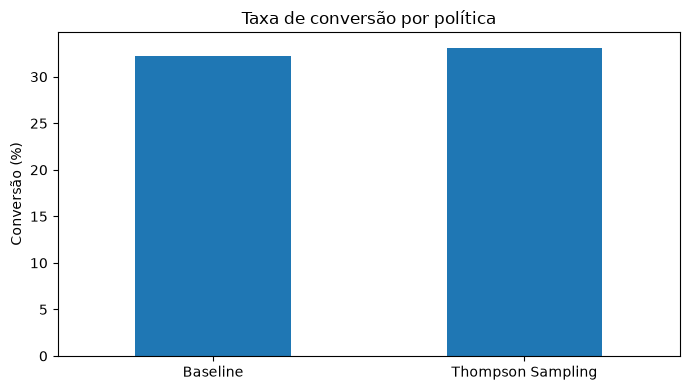

In [7]:
metrics_df.plot(
    x="policy",
    y="conversion_rate_pct",
    kind="bar",
    legend=False,
    figsize=(7, 4)
)

plt.title("Taxa de conversão por política")
plt.xlabel("")
plt.ylabel("Conversão (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

No replay final, a taxa de conversão deve ser analisada junto com a cobertura. Como os dados não possuem a recompensa das ações que não foram realizadas, políticas diferentes podem ser avaliadas sobre quantidades diferentes de interações.

## Robustez do Thompson Sampling

In [8]:
runs = []

for seed in range(30):
    metrics = run_thompson_replay(
        history_df,
        test_df,
        seed=seed
    )

    runs.append({
        "seed": seed,
        "conversion_rate": metrics["conversion_rate"],
        "coverage": metrics["coverage"]
    })

robustness_df = pd.DataFrame(runs)

print(
    f"Conversão média: "
    f"{robustness_df['conversion_rate'].mean() * 100:.2f}%"
)

print(
    f"Desvio padrão: "
    f"{robustness_df['conversion_rate'].std() * 100:.2f} p.p."
)

print(
    f"Cobertura média: "
    f"{robustness_df['coverage'].mean() * 100:.2f}%"
)

Conversão média: 32.42%
Desvio padrão: 0.77 p.p.
Cobertura média: 81.87%


## Golden Set

Para os exemplos abaixo, o estado da política é construído somente com o histórico anterior ao conjunto de teste.

A recomendação do Golden Set usa a média posterior de cada braço. Isso deixa os 5 casos determinísticos e fáceis de reproduzir.

In [9]:
def build_posterior(history_df):
    arms = sorted(history_df["arm"].unique())

    alpha = {}
    beta = {}

    for context in ["none", "one", "two_plus"]:
        for arm in arms:
            alpha[(context, arm)] = 1
            beta[(context, arm)] = 1

    for context, arm, reward in history_df[
        ["previous_group", "arm", "reward"]
    ].itertuples(index=False, name=None):

        key = (str(context), arm)

        alpha[key] += reward
        beta[key] += 1 - reward

    return arms, alpha, beta


arms, alpha, beta = build_posterior(history_df)

In [10]:
posterior_rows = []

for context in ["none", "one", "two_plus"]:
    row = {"previous_group": context}

    for arm in arms:
        row[f"{arm}_estimate"] = (
            alpha[(context, arm)]
            / (
                alpha[(context, arm)]
                + beta[(context, arm)]
            )
        )

        row[f"{arm}_observations"] = (
            alpha[(context, arm)]
            + beta[(context, arm)]
            - 2
        )

    posterior_rows.append(row)

posterior_df = pd.DataFrame(posterior_rows)

posterior_df

,previous_group,cellular_estimate,cellular_observations,telephone_estimate,telephone_observations
0,none,0.080246,16734,0.040982,13931
1,one,0.079785,2041,0.079646,111
2,two_plus,0.152542,116,0.222222,7


In [11]:
golden_set = pd.concat([
    test_df[test_df["previous_group"] == "none"].head(2),
    test_df[test_df["previous_group"] == "one"].head(2),
    test_df[test_df["previous_group"] == "two_plus"].head(1)
]).copy()

golden_set = golden_set[
    [
        "interaction_id",
        "age",
        "job",
        "education",
        "poutcome",
        "previous",
        "previous_group"
    ]
].reset_index(drop=True)

golden_set.insert(
    0,
    "client_id",
    [f"client_{i}" for i in range(1, 6)]
)

golden_set

,client_id,interaction_id,age,job,education,poutcome,previous,previous_group
0,client_1,32950,44,blue-collar,basic.6y,nonexistent,0,none
1,client_2,32953,28,blue-collar,professional.course,nonexistent,0,none
2,client_3,32951,31,technician,university.degree,failure,1,one
3,client_4,32952,29,blue-collar,basic.9y,failure,1,one
4,client_5,33019,29,blue-collar,basic.9y,failure,2,two_plus


In [12]:
def recommend(context):
    context = str(context)

    estimates = {
        arm: (
            alpha[(context, arm)]
            / (
                alpha[(context, arm)]
                + beta[(context, arm)]
            )
        )
        for arm in arms
    }

    recommended_arm = max(
        estimates,
        key=estimates.get
    )

    return (
        recommended_arm,
        estimates["cellular"],
        estimates["telephone"]
    )


def explain_decision(row):
    if row["previous_group"] == "none":
        return (
            "Faz sentido: cellular tem estimativa maior "
            "e existe bastante histórico nesse grupo."
        )

    if row["previous_group"] == "one":
        return (
            "Faz sentido, mas as estimativas são muito próximas. "
            "É um contexto em que ainda existe incerteza."
        )

    return (
        "Faz sentido com ressalva: telephone tem estimativa maior, "
        "mas há poucas observações históricas nesse grupo."
    )


recommendations = golden_set["previous_group"].astype(str).apply(
    recommend
)

golden_set[
    [
        "recommended_arm",
        "cellular_estimate",
        "telephone_estimate"
    ]
] = pd.DataFrame(
    recommendations.tolist(),
    index=golden_set.index
)

golden_set["analysis"] = golden_set.apply(
    explain_decision,
    axis=1
)

golden_set["cellular_estimate"] = (
    golden_set["cellular_estimate"] * 100
).round(2)

golden_set["telephone_estimate"] = (
    golden_set["telephone_estimate"] * 100
).round(2)

golden_set[
    [
        "client_id",
        "age",
        "job",
        "previous",
        "previous_group",
        "recommended_arm",
        "cellular_estimate",
        "telephone_estimate",
        "analysis"
    ]
]

,client_id,age,job,previous,previous_group,recommended_arm,cellular_estimate,telephone_estimate,analysis
0,client_1,44,blue-collar,0,none,cellular,8.02,4.10,Faz sentido: cellular tem estimativa maior e e...
1,client_2,28,blue-collar,0,none,cellular,8.02,4.10,Faz sentido: cellular tem estimativa maior e e...
2,client_3,31,technician,1,one,cellular,7.98,7.96,"Faz sentido, mas as estimativas são muito próx..."
3,client_4,29,blue-collar,1,one,cellular,7.98,7.96,"Faz sentido, mas as estimativas são muito próx..."
4,client_5,29,blue-collar,2,two_plus,telephone,15.25,22.22,Faz sentido com ressalva: telephone tem estima...


### Leitura dos casos

O Golden Set não tenta provar qual seria o resultado contrafactual para cada cliente. Ele serve para verificar se a recomendação produzida pela política é coerente com o histórico aprendido.

Nos grupos com poucas observações, a recomendação deve ser tratada com mais cautela, mesmo quando uma das médias posteriores é maior.

## Conclusão

A avaliação final confirma o ganho observado pelo Thompson Sampling em relação ao baseline no replay offline.

Além da execução com seed fixa, as múltiplas execuções ajudam a verificar a estabilidade da política. O Golden Set mostra como a recomendação pode ser inspecionada em exemplos individuais e também evidencia situações em que a quantidade de histórico ainda é pequena.

Essas limitações serão importantes na implementação da API e na descrição de como a solução poderia ser monitorada em produção.